MODEL 3 (BEST FITTED MODEL) ALL PARTS SOLVED FOR THIS MODEL


Parameter           Estimate         Std.Error      95% CI Lower      95% CI Upper
Theta_0         1.22897603        0.13550470        0.95792628        1.50002578
Theta_1         0.05909229        0.02798563        0.00311269        0.11507189
Theta_2        -0.00212339        0.00170580       -0.00553550        0.00128872
Theta_3         0.00003054        0.00003869       -0.00004686        0.00010794
Theta_4        -0.00000015        0.00000029       -0.00000074        0.00000043

Least squares error: 2.36782441
Estimated σ² (sigma²_hat):     0.03946374

Shapiro–Wilk Test for Normality
Test Statistic: 0.97962861
p-value:        0.35938852



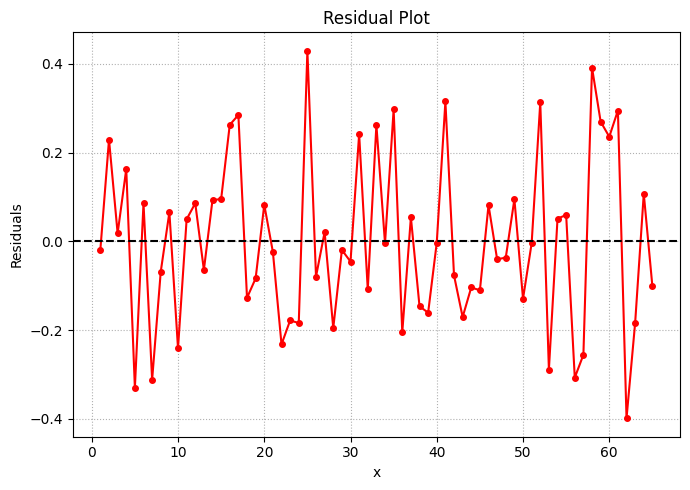

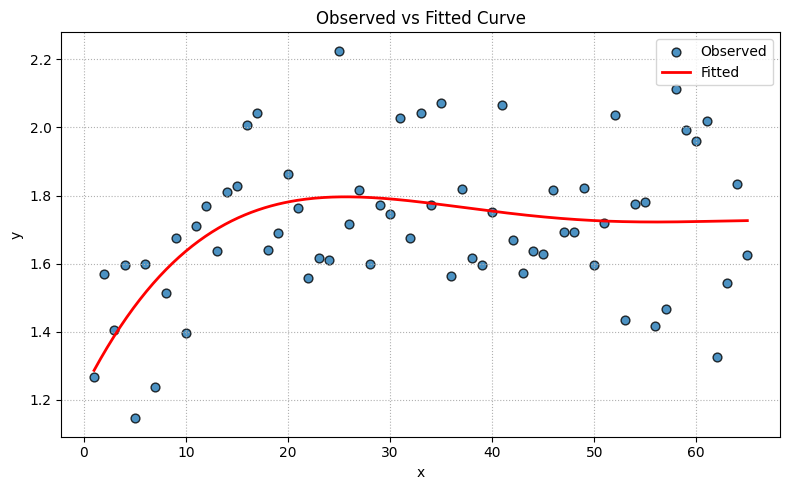

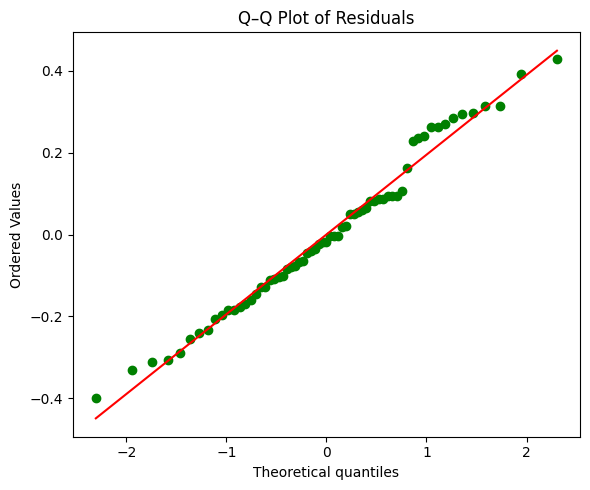

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, shapiro, probplot

# Data
x = np.arange(1, 66)
y = np.array([
    1.2675699, 1.56836522, 1.40598726, 1.5963099, 1.14503253, 1.59949017,
    1.23664796, 1.51268291, 1.67563486, 1.39548397, 1.71029735, 1.76775706,
    1.63671231, 1.81146705, 1.82786596, 2.00845766, 2.04187417, 1.63927615,
    1.69111669, 1.86361861, 1.76239586, 1.55807352, 1.61499798, 1.61091864,
    2.22563457, 1.7166146, 1.81661677, 1.59862912, 1.77303874, 1.7444241,
    2.02902102, 1.67581379, 2.04310727, 1.7726599, 2.07083535, 1.56434131,
    1.81987619, 1.61538935, 1.59715497, 1.75117481, 2.06559062, 1.66998506,
    1.57279253, 1.63657176, 1.62683678, 1.81609595, 1.69165778, 1.69335938,
    1.82298696, 1.59717536, 1.72062469, 2.03732061, 1.43416905, 1.77371311,
    1.78190637, 1.41504908, 1.46671343, 2.11406517, 1.99274874, 1.95925045,
    2.01894283, 1.32584739, 1.54172075, 1.83312881, 1.62474573
])

# Design matrix for degree 4 polynomial
X = np.column_stack([np.ones_like(x), x, x**2, x**3, x**4])

# Fit model
theta = np.linalg.solve(X.T @ X, X.T @ y)
y_hat = X @ theta
residuals = y - y_hat

# Key statistics
n, p = len(x), len(theta)
RSS = np.sum(residuals**2)
sigma2_hat = RSS / (n - p)

# Confidence intervals
XtX_inv = np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(sigma2_hat * XtX_inv))
t_crit = t.ppf(0.975, df=n - p)
ci_low, ci_high = theta - t_crit * se, theta + t_crit * se


print(f"{'Parameter':<10}{'Estimate':>18}{'Std.Error':>18}{'95% CI Lower':>18}{'95% CI Upper':>18}")
for i in range(p):
    print(f"Theta_{i:<2}{theta[i]:>18.8f}{se[i]:>18.8f}{ci_low[i]:>18.8f}{ci_high[i]:>18.8f}")
print(f"\nLeast squares error: {RSS:.8f}")
print(f"Estimated σ² (sigma²_hat):     {sigma2_hat:.8f}\n")

# Normality test
stat, pval = shapiro(residuals)
print("Shapiro–Wilk Test for Normality")
print(f"Test Statistic: {stat:.8f}")
print(f"p-value:        {pval:.8f}\n")

# Residual plot
plt.figure(figsize=(7, 5))
plt.plot(x, residuals, 'o-', color='red', ms=4)
plt.axhline(0, color='black', ls='--')
plt.title("Residual Plot")
plt.xlabel("x")
plt.ylabel("Residuals")
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

# Observed vs fitted
x_s = np.linspace(x.min(), x.max(), 300)
X_s = np.column_stack([np.ones_like(x_s), x_s, x_s**2, x_s**3, x_s**4])
y_s = X_s @ theta

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=40, alpha=0.8, edgecolor='k', label='Observed')
plt.plot(x_s, y_s, 'r-', lw=2, label='Fitted')
plt.title("Observed vs Fitted Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

# Q–Q plot
plt.figure(figsize=(6, 5))
ax = plt.gca()
probplot(residuals, dist="norm", plot=ax)
ax.get_lines()[0].set_color("green")
ax.get_lines()[1].set_color("red")
ax.set_title("Q–Q Plot of Residuals")
plt.tight_layout()
plt.show()


MODEL 1


alpha0 = 1.75615368
alpha1 = 0.18838236
alpha2 = -0.76356453
beta1  = -0.12137443
beta2  = -0.15313773
least squares error   = 2.4626714603


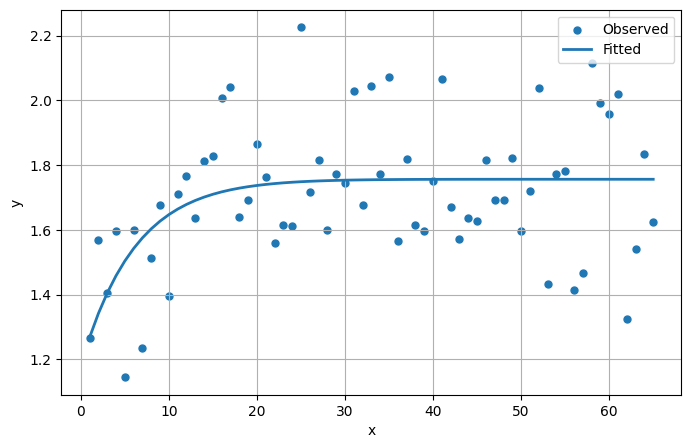

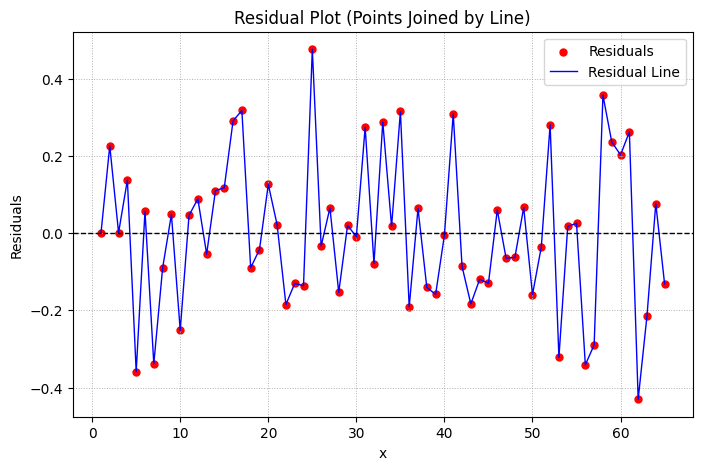

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def sexp(x):
    return np.exp(np.clip(x, -700, 700))

def X_mat(b1, b2, x):
    e1 = sexp(b1 * x)
    e2 = sexp(b2 * x)
    return np.column_stack([np.ones_like(x), e1, e2])

def alpha_Xinv(b1, b2, x, y):
    X = X_mat(b1, b2, x)
    XtX = X.T @ X
    XtX_inv = np.linalg.pinv(XtX)
    a = XtX_inv @ (X.T @ y)
    return a, XtX_inv, X

def Q_proj(b):
    b1, b2 = b
    a, XtX_inv, X = alpha_Xinv(b1, b2, x, y)
    v = X.T @ y
    u = XtX_inv @ v
    return float(v.T @ u)

def grad(b):
    eps = 1e-6
    p = b.size
    g = np.zeros(p, dtype=float)
    j = 0
    while j < p:
        e = np.zeros(p); e[j] = 1.0
        f_plus  = -Q_proj(b + eps * e)
        f_minus = -Q_proj(b - eps * e)
        g[j] = (f_plus - f_minus) / (2.0 * eps)
        j += 1
    return g.reshape(-1, 1)

def hess(b):
    eps = 1e-5
    p = b.size
    H = np.zeros((p, p), dtype=float)
    i = 0
    while i < p:
        j = 0
        while j < p:
            ei = np.zeros(p); ei[i] = 1.0
            ej = np.zeros(p); ej[j] = 1.0
            fpp = -Q_proj(b + eps*ei + eps*ej)
            fpm = -Q_proj(b + eps*ei - eps*ej)
            fmp = -Q_proj(b - eps*ei + eps*ej)
            fmm = -Q_proj(b - eps*ei - eps*ej)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
            j += 1
        i += 1
    return H

def newton(b0):
    max_iter = 50
    tol_g = 1e-8
    tol_s = 1e-9
    damping = True
    max_bt = 25

    b = np.asarray(b0, float).copy()
    k = 0
    Qf = lambda z: -Q_proj(z)

    while k < max_iter:
        Q0 = Qf(b)
        g = grad(b).ravel()
        if np.linalg.norm(g) < tol_g:
            break
        H = hess(b)
        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            d = -np.linalg.pinv(H) @ g
        if np.linalg.norm(d) < tol_s:
            break
        step = 1.0
        bt = 0
        b_try = b + step * d
        Q_try = Qf(b_try)
        if damping:
            while Q_try > Q0 and bt < max_bt:
                step *= 0.5
                b_try = b + step * d
                Q_try = Qf(b_try)
                bt += 1
        b = b_try
        k += 1
    return b

# data
x = np.array([1,2,3,4,5,6,7,8,9,10,
              11,12,13,14,15,16,17,18,19,20,
              21,22,23,24,25,26,27,28,29,30,
              31,32,33,34,35,36,37,38,39,40,
              41,42,43,44,45,46,47,48,49,50,
              51,52,53,54,55,56,57,58,59,60,
              61,62,63,64,65], dtype=float)

y = np.array([
    1.2675699, 1.56836522, 1.40598726, 1.5963099, 1.14503253, 1.59949017,
    1.23664796, 1.51268291, 1.67563486, 1.39548397, 1.71029735, 1.76775706,
    1.63671231, 1.81146705, 1.82786596, 2.00845766, 2.04187417, 1.63927615,
    1.69111669, 1.86361861, 1.76239586, 1.55807352, 1.61499798, 1.61091864,
    2.22563457, 1.7166146, 1.81661677, 1.59862912, 1.77303874, 1.7444241,
    2.02902102, 1.67581379, 2.04310727, 1.7726599, 2.07083535, 1.56434131,
    1.81987619, 1.61538935, 1.59715497, 1.75117481, 2.06559062, 1.66998506,
    1.57279253, 1.63657176, 1.62683678, 1.81609595, 1.69165778, 1.69335938,
    1.82298696, 1.59717536, 1.72062469, 2.03732061, 1.43416905, 1.77371311,
    1.78190637, 1.41504908, 1.46671343, 2.11406517, 1.99274874, 1.95925045,
    2.01894283, 1.32584739, 1.54172075, 1.83312881, 1.62474573
], dtype=float)

# fit
b_init = np.array([-0.4, -0.1], dtype=float)
b_hat = newton(b_init)
a_hat, _, X = alpha_Xinv(b_hat[0], b_hat[1], x, y)

a0, a1, a2 = a_hat
b1, b2 = b_hat
y_hat = a0 + a1 * sexp(b1 * x) + a2 * sexp(b2 * x)
res = y - y_hat
SSE = float(np.sum(res**2))


print(f"alpha0 = {a0:.8f}")
print(f"alpha1 = {a1:.8f}")
print(f"alpha2 = {a2:.8f}")
print(f"beta1  = {b1:.8f}")
print(f"beta2  = {b2:.8f}")
print(f"least squares error   = {SSE:.10f}")

# plots
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=25, label="Observed")
plt.plot(x, y_hat, linewidth=2, label="Fitted")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(x, res, s=25, color="red", label="Residuals")
plt.plot(x, res, color="blue", linewidth=1, label="Residual Line")  # connects points
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("Residuals")
plt.title("Residual Plot (Points Joined by Line)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()




MODEL 2

beta0 = -32.77798030
beta1 = -10.41029885
alpha0 = -36.36724350
alpha1 = -18.80740319
least squares error = 2.5497722310


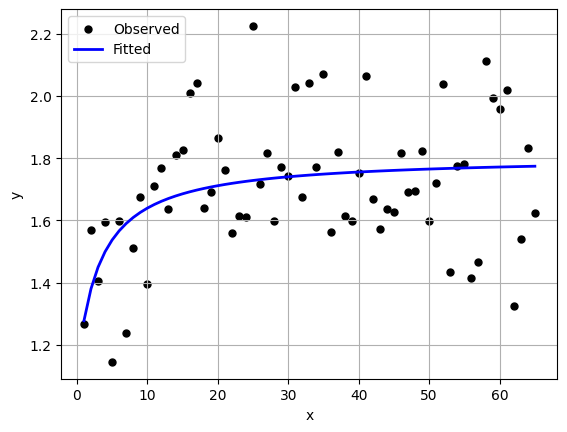

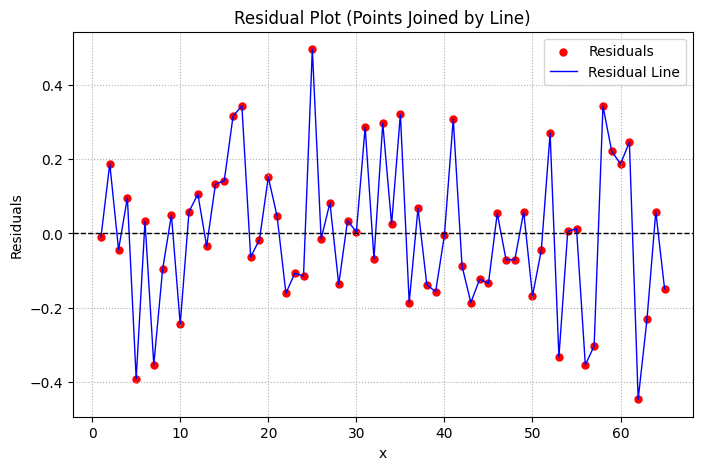

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def X_matrix(b0, b1, x):
    eps = 1e-12
    d = b0 + b1 * x
    d = np.where(np.abs(d) < eps, np.sign(d) * eps + eps, d)
    return np.column_stack([1.0 / d, x / d])

def alpha_and_XtXinv(b0, b1, x, y):
    X = X_matrix(b0, b1, x)
    XtX = X.T @ X
    XtX_inv = np.linalg.pinv(XtX)
    a = XtX_inv @ (X.T @ y)
    return a, XtX_inv, X

def Q_via_projection(b, x, y):
    b0, b1 = b
    a, XtX_inv, X = alpha_and_XtXinv(b0, b1, x, y)
    v = X.T @ y
    u = XtX_inv @ v
    return float(v.T @ u)

def grad(b, x, y):
    eps = 1e-6
    g = np.zeros_like(b)
    for j in range(len(b)):
        e = np.zeros_like(b)
        e[j] = 1.0
        f_plus  = -Q_via_projection(b + eps * e, x, y)
        f_minus = -Q_via_projection(b - eps * e, x, y)
        g[j] = (f_plus - f_minus) / (2.0 * eps)
    return g.reshape(-1, 1)

def hessian(b, x, y):
    eps = 1e-5
    p = len(b)
    H = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            e_i = np.zeros(p); e_i[i] = 1.0
            e_j = np.zeros(p); e_j[j] = 1.0
            f_pp = -Q_via_projection(b + eps*e_i + eps*e_j, x, y)
            f_pm = -Q_via_projection(b + eps*e_i - eps*e_j, x, y)
            f_mp = -Q_via_projection(b - eps*e_i + eps*e_j, x, y)
            f_mm = -Q_via_projection(b - eps*e_i - eps*e_j, x, y)
            H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * eps**2)
    return H

def newton_iterate(b0, x, y):
    max_iter = 50
    tol_grad = 1e-8
    tol_step = 1e-9
    damping = True
    max_backtracks = 25

    b = np.asarray(b0, dtype=float).copy()
    k = 0
    Qfunc = lambda b: -Q_via_projection(b, x, y)

    while k < max_iter:
        Qval = Qfunc(b)
        g = grad(b, x, y).ravel()
        gnorm = np.linalg.norm(g)
        if gnorm < tol_grad:
            break
        H = hessian(b, x, y)
        try:
            delta = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            delta = -np.linalg.pinv(H) @ g
        step_norm = np.linalg.norm(delta)
        if step_norm < tol_step:
            break

        step = 1.0
        beta_trial = b + step * delta
        Q_trial = Qfunc(beta_trial)
        bt_count = 0
        if damping:
            while Q_trial > Qval and bt_count < max_backtracks:
                step *= 0.5
                beta_trial = b + step * delta
                Q_trial = Qfunc(beta_trial)
                bt_count += 1
        b = beta_trial
        k += 1
    return b

# ---------------------------
# Data
# ---------------------------
x = np.arange(1, 66)
y = np.array([
    1.2675699,1.56836522,1.40598726,1.5963099,1.14503253,1.59949017,
    1.23664796,1.51268291,1.67563486,1.39548397,1.71029735,1.76775706,
    1.63671231,1.81146705,1.82786596,2.00845766,2.04187417,1.63927615,
    1.69111669,1.86361861,1.76239586,1.55807352,1.61499798,1.61091864,
    2.22563457,1.7166146,1.81661677,1.59862912,1.77303874,1.7444241,
    2.02902102,1.67581379,2.04310727,1.7726599,2.07083535,1.56434131,
    1.81987619,1.61538935,1.59715497,1.75117481,2.06559062,1.66998506,
    1.57279253,1.63657176,1.62683678,1.81609595,1.69165778,1.69335938,
    1.82298696,1.59717536,1.72062469,2.03732061,1.43416905,1.77371311,
    1.78190637,1.41504908,1.46671343,2.11406517,1.99274874,1.95925045,
    2.01894283,1.32584739,1.54172075,1.83312881,1.62474573
])

# ---------------------------
# Fit
# ---------------------------
b_init = np.array([-1.0, -1e-8])
b_hat = newton_iterate(b_init, x, y)
a_hat, _, X = alpha_and_XtXinv(b_hat[0], b_hat[1], x, y)
a0, a1 = a_hat
b0, b1 = b_hat

y_hat = (a0 + a1*x) / (b0 + b1*x)
res = y - y_hat
SSE = np.sum(res**2)

print(f"beta0 = {b0:.8f}\nbeta1 = {b1:.8f}")
print(f"alpha0 = {a0:.8f}\nalpha1 = {a1:.8f}")
print(f"least squares error = {SSE:.10f}")

plt.scatter(x, y, color="black", s=25, label="Observed")
plt.plot(x, y_hat, color="blue", linewidth=2, label="Fitted")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(x, res, color="red", s=25, label="Residuals")
plt.plot(x, res, color="blue", linewidth=1, label="Residual Line")  # joins residual points
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("x"); plt.ylabel("Residuals")
plt.title("Residual Plot (Points Joined by Line)")
plt.legend(); plt.grid(True, linestyle=":")
plt.show()

